In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs_pure
import loglike_pure   # NON-timemax, NON-phasemax
import parismc
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10     # Time step
T = 3/12     # Total time

print(f"Using dt = {dt} seconds, T = {T} years")

inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0,
        "include_minus_m": False,
}

amplitude_kwargs = {
    "force_backend": force_backend
}

Ylm_kwargs = {
    "force_backend": force_backend,
}

sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1,6)
ell = 2

loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None
)

print('Done initializing loglike class.')

data     = loglike_obj.signal
data_snr = float(gwf.rhostat(data))
print('SNR:', data_snr)


Using dt = 10 seconds, T = 0.25 years
Creating GenerateEMRIWaveform class...


KeyboardInterrupt: 

In [ ]:
pwd

'/nfs/home/svu/e1498138/localgit/FEWNEW/work'

In [ ]:
# prior bounds
_p2_lo = np.array([5.6, 0.8, 0.3, 8.0, 0.2])
_p2_hi = np.array([6.4, 1.3, 0.99, 11.0, 0.5])

def log_density(params):      
    raise RuntimeError("stub")

def prior_transform(u):
    return _p2_lo + (_p2_hi - _p2_lo) * u
sampler_2 = parismc.Sampler.load_state(
    './search/intrinsic_ffunc_3mth_snr32_paris2/sampler_state.pkl'
)

S_ANNEAL = 30

# Max logden point from paris2_1 (in physical space)
all_pts_u  = sampler_2.searched_points_list[0]
all_logden = sampler_2.searched_log_densities_list[0]
maxld_idx  = np.argmax(all_logden)
mu_center  = prior_transform(all_pts_u[maxld_idx].reshape(1, -1))[0]
print(f'stage 2 maxld: {all_logden[maxld_idx]:.4f}')
print(f'stage 2 maxld point:    {mu_center}')

# Posterior covariance from paris2_1: importance-weight resample then np.cov
samples_p2, weights_p2 = sampler_2.get_samples_with_weights(flatten=True)
weights_p2 = weights_p2 / weights_p2.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples_p2), size=50_000, replace=True, p=weights_p2)
cov_posterior = S_ANNEAL* np.cov(samples_p2[idx_rs].T)  # physical-space posterior covariance
print('stage 2 posterior 1-sigma (diag, using S):', np.sqrt(np.diag(cov_posterior)))



stage 2 maxld: 590.5817
stage 2 maxld point:    [6.01487994 1.00500901 0.73205648 8.81696887 0.39543265]
stage 2 posterior 1-sigma (diag, using S): [0.05092219 0.02858921 0.10509759 0.60402487 0.02137137]


In [ ]:
del sampler_2, samples_p2, weights_p2, idx_rs  # free memory


In [ ]:
# Define prior_transform matching paris3_2's ellipse bounds                                                                                                                 
ellipse_lo = np.array([5.98699, 0.98935, 0.67449, 8.48613, 0.38373])                                                                                                        
ellipse_hi = np.array([6.04277, 1.02067, 0.78962, 9.14781, 0.40714])                                                                                                        
                                                                                                                                                                        
N_SIGMA_PRIOR = 1.0 
# _TARGET_LOGLIKE = data_snr # only stop once hit target
_TARGET_LOGLIKE = loglike_obj(np.array(params_star))

def log_density(params):
    global _EARLY_STOP_HIT
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        if _EARLY_STOP_HIT:
            log_likes[i] = -np.inf
            continue

        logm1, logm2, a_i, p0_i, e0_i = params[i]

        # Ellipse guard: reject points outside N_SIGMA_PRIOR ellipse
        diff  = params[i] - mu_center
        maha2 = diff @ cov_inv @ diff
        if maha2 > N_SIGMA_PRIOR ** 2:
            log_likes[i] = -np.inf
            continue

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf

        if np.isfinite(loglike) and loglike >= _TARGET_LOGLIKE:
            _EARLY_STOP_HIT = True
            print(f'[EARLY-STOP] loglike {loglike:.6f} >= target {_TARGET_LOGLIKE:.6f}; future calls => -inf', flush=True)

        log_likes[i] = loglike

    return log_likes                                                                                                                
                                                                                                                                                                            
def prior_transform(u):                                                                                                                                                   
    return ellipse_lo + (ellipse_hi - ellipse_lo) * u                                                                                                                       
                                                                                                                                                                        
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris3_3/sampler_state.pkl')                                                                      
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [ ]:
# Tight bounding box: mu_center ± N_SIGMA_PRIOR * sigma, clipped to original prior
sigma_diag  = np.sqrt(np.diag(cov_posterior))
ellipse_lo  = np.clip(mu_center - N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
ellipse_hi  = np.clip(mu_center + N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
cov_inv     = np.linalg.inv(cov_posterior)



In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.5       , 0.5       , 0.5       , 0.5       , 0.5       ],
        [0.60250462, 0.74042599, 0.57431428, 0.42665773, 0.28735059],
        [0.8075704 , 0.61232766, 0.83152845, 0.16876784, 0.32905911],
        ...,
        [0.55523448, 0.6150219 , 0.5432768 , 0.45771411, 0.39862213],
        [0.43318157, 0.53517406, 0.41505221, 0.58379165, 0.49149566],
        [0.41189147, 0.30706345, 0.4359826 , 0.56435818, 0.6723401 ]],
       shape=(200000, 5))]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([149.49906613,   0.16652133,  -0.21651117, ...,   0.92807006,
          2.92283824,  -0.18019989], shape=(200000,))]

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.00362091, 1.00214577, 0.70734596, 8.95862774, 0.39836842]])

In [ ]:
_EARLY_STOP_HIT=False
log_density(maxld_pt1)

array([-0.01361975])

In [ ]:
log_density([param_true])

array([-inf])

In [ ]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [ ]:
gwf.rhostat(h_pt1)

array(5.95799413)

In [ ]:
gwf.Xstat(data, data)

array(5.94213445)

In [ ]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(5.8099132), array(0.59622769))

In [ ]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

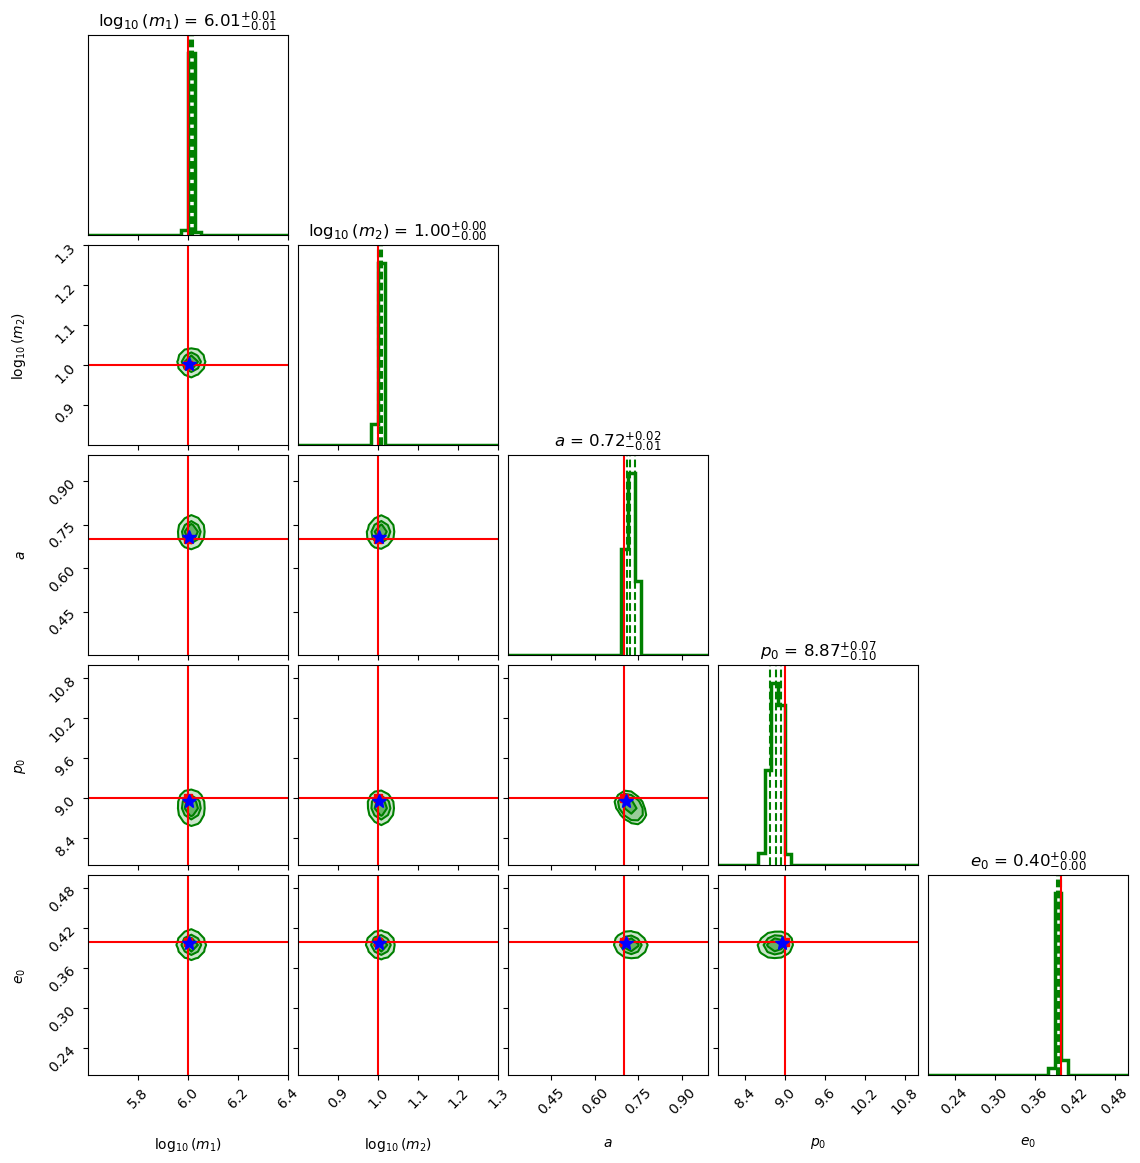

In [ ]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




#  connection

In [ ]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.00362091, 1.00214577, 0.70734596, 8.95862774, 0.39836842]])

In [20]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [21]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


[EARLY-STOP] loglike 5.907163 >= target 5.907163; future calls => -inf


In [22]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


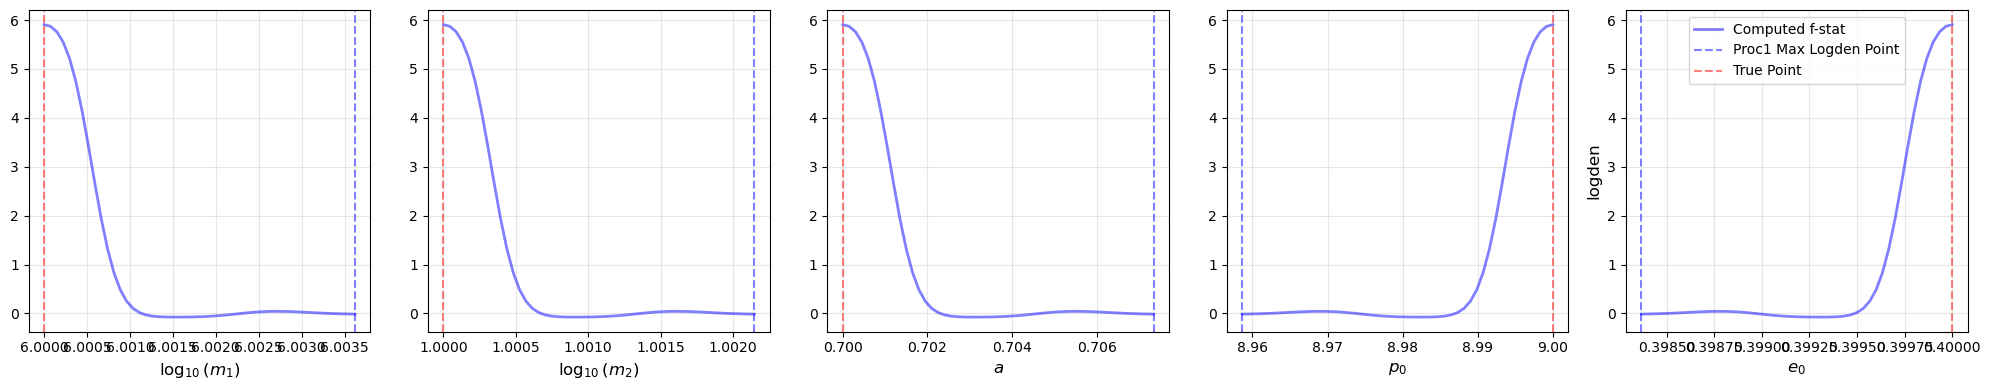

In [23]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
